## Лаба 2

#### Задание 1.  Цель: Закрепление основных команд первичного анализа данных в Pandas

In [80]:
import pandas as pd #подключаем библиотеку

In [81]:
ratings = pd.read_csv("ratings.dat", sep="::", engine="python", encoding="latin-1", names=["UserID","MovieID","Rating","Timestamp"])

In [82]:
movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python", #переделать на питон
    names=["MovieID","Title","Genres"], #сделала список имен  для столбцов
    encoding="latin-1" #если есть символы, подкорректирует и выдаст то, что надо
)

In [83]:
users = pd.read_csv(
    "users.dat",
    sep="::",
    engine="python",
    names=["UserID","Gender","Age","Occupation","Zip-Code"],
    encoding="latin-1"
)

In [84]:
data = pd.merge(ratings,users,on="UserID") #объединение таблиц
data = pd.merge(data,movies,on="MovieID")

data.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-Code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


2. Требуется вычислить средние рейтинги для фильма с ID = № варианта в зависимости 
от пола

In [85]:
movie = data[data["MovieID"] == 10] #из таблицы data берем столбец MovieID, рейтинг которого 10

result = movie.groupby("Gender")["Rating"].mean() #группируем данные по Gender и посчитала средний рейтинг
result = result.reset_index()

print(result)
movie["Title"].head(1)

  Gender    Rating
0      F  3.470149
1      M  3.553050


1395    GoldenEye (1995)
Name: Title, dtype: str

2. Отобрать фильмы, получившие не менее 250 оценок, и для них определить средний 
рейтинг в зависимости от пола;
Результат вывести в виде DataFrame с колонками 
['MovieID', 'Title', 'Rating_F', 'Rating_M']

In [89]:
count = data.groupby("MovieID")["Rating"].count() #считаем кол-во оценок у каждого фильма

popular = count[count >= 250].index #выдает индексы с фильмами оценок больше 250
a = data[data["MovieID"].isin(popular)] #оставляем только эти фильмы
#isin() проверяет входит ли MovieID в список популярных
result = a.groupby(["MovieID", "Title", "Gender"])["Rating"].mean().unstack() #считаем средний рейтинг по полу; возьмет внутренний индекс рейтинг и перенесет его в стобцы
result = result.rename(columns={"F":"Rating_F", "M":"Rating_M"}) #переименовываем столбцы
result = result.reset_index() #делаем таблицу DataFrame
result.head()

Gender,MovieID,Title,Rating_F,Rating_M
0,1,Toy Story (1995),4.187817,4.130552
1,2,Jumanji (1995),3.278409,3.175238
2,3,Grumpier Old Men (1995),3.073529,2.994152
3,5,Father of the Bride Part II (1995),3.212963,2.888298
4,6,Heat (1995),3.682171,3.909988


3. Найти фильмы, оказавшиеся в топ 5 у зрителей-женщин и худшие 5 у зрителей мужчин. Найти фильмы (топ 5), по которым мужчины и женщины сильнее всего разошлись в оценках

In [90]:
top_f = result.sort_values("Rating_F", ascending=False).head(5) #сортируем от большего к меньшему
top_f

Gender,MovieID,Title,Rating_F,Rating_M
212,745,"Close Shave, A (1995)",4.644444,4.473795
336,1148,"Wrong Trousers, The (1993)",4.588235,4.478261
255,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.572650,4.464589
206,720,Wallace & Gromit: The Best of Aardman Animatio...,4.563107,4.385075
162,527,Schindler's List (1993),4.562602,4.491415


In [11]:
top_f = result.sort_values("Rating_M", ascending=False).head(5)
top_f

Gender,MovieID,Title,Rating_F,Rating_M
232,858,"Godfather, The (1972)",4.314700,4.583333
638,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.481132,4.576628
93,318,"Shawshank Redemption, The (1994)",4.539075,4.560625
349,1198,Raiders of the Lost Ark (1981),4.332168,4.520597
24,50,"Usual Suspects, The (1995)",4.513317,4.518248


In [ ]:
result["Difference"] = (result["Rating_F"] - result["Rating_M"]).abs() #создаю столбец с разнице рейтингов; abs() - модуль, чтобы число было +
top_diff = result.sort_values("Difference", ascending=False).head(5) #сортирую по разнице; ascending=False - от большего к меньшему
top_diff

Gender,MovieID,Title,Rating_F,Rating_M,Difference
313,1088,Dirty Dancing (1987),3.790378,2.959596,0.830782
352,1201,"Good, The Bad and The Ugly, The (1966)",3.494949,4.221300,0.726351
1186,3760,"Kentucky Fried Movie, The (1977)",2.878788,3.555147,0.676359
796,2468,Jumpin' Jack Flash (1986),3.254717,2.578358,0.676359
68,231,Dumb & Dumber (1994),2.697987,3.336595,0.638608


4. Определить фильмы (топ 5), вызвавшие в среднем наибольшее разногласие у зрителей 
независимо от пола

In [92]:
count = data.groupby(["MovieID", "Title", "Gender"])["Rating"].std()
count = count.reset_index() #делаю Series в таблицу

top = count.sort_values("Rating", ascending= False).head(5) #сортируем от большего кол-ва к меньшему

top

,MovieID,Title,Gender,Rating
1073,559,"Paris, France (1993)",F,2.828427
1098,572,Foreign Student (1994),M,2.828427
3307,1899,Passion in the Desert (1998),F,2.828427
5439,3021,"Funhouse, The (1981)",F,2.828427
6986,3866,Sunset Strip (2000),F,2.828427


5. Определить средний рейтинг каждого жанра для различных возрастов. Установите, 
фильмы какого жанра в каждой категории возрастов имеют наибольший и наименьший 
рейтинги.
Если фильм относится к нескольким данным, то их надо разделить и сформировать 
несколько строчек с этим фильмом, но с различными жанрами.


In [16]:
#объеденяю таблицы
data = pd.merge(ratings, users, on = "UserID")
data = pd.merge(data, movies, on = "MovieID")

data["Genres"] = data["Genres"].str.split("|") #разделяю жанры
data = data.explode("Genres") #делаю отдельную строку для каждого жанра

genre_age = data.groupby(["Age", "Genres"])["Rating"].mean() #считаю средний рейтинг

genre_age = genre_age.reset_index() #переделываю Series в DF

genre_age


,Age,Genres,Rating
0,1,Action,3.506385
1,1,Adventure,3.449975
2,1,Animation,3.476113
3,1,Children's,3.241642
4,1,Comedy,3.497491
...,...,...,...
121,56,Romance,3.816531
122,56,Sci-Fi,3.497746
123,56,Thriller,3.719749
124,56,War,4.067285


In [97]:
max = genre_age.sort_values(["Age", "Rating"], ascending=[True, False])
max = max.groupby("Age").head(1)
max

,Age,Genres,Rating
9,1,Film-Noir,4.145455
27,18,Film-Noir,3.997368
45,25,Film-Noir,4.058725
63,35,Film-Noir,4.064910
81,45,Film-Noir,4.105376
99,50,Film-Noir,4.175401
117,56,Film-Noir,4.125932


In [98]:
min = genre_age.sort_values(["Age", "Rating"])
min = min.groupby("Age").head(1)
min

,Age,Genres,Rating
3,1,Children's,3.241642
28,18,Horror,3.172682
46,25,Horror,3.200096
64,35,Horror,3.276022
82,45,Horror,3.262274
100,50,Horror,3.158940
118,56,Horror,3.254401


#### Задание 2. Цель: Закрепление основных понятий теории вероятностей

1.  Случайная величина X имеет нормальное распределение, M[X] = 10 и D[X] = 4.

Построить функцию и плотность распределения вероятностей для нормированной нормально распределенной случайной величины.

Построить функцию и плотность распределения вероятностей для X.

Вычислить вероятности P(X < 11), P(X > 5), P(4 < X < 12).

Отобразить, вероятности на графиках функции  и плотности вероятностей.

Проверить выполнение правила «3-сигм» для X, отобразить это правило на графике плотности вероятностей

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

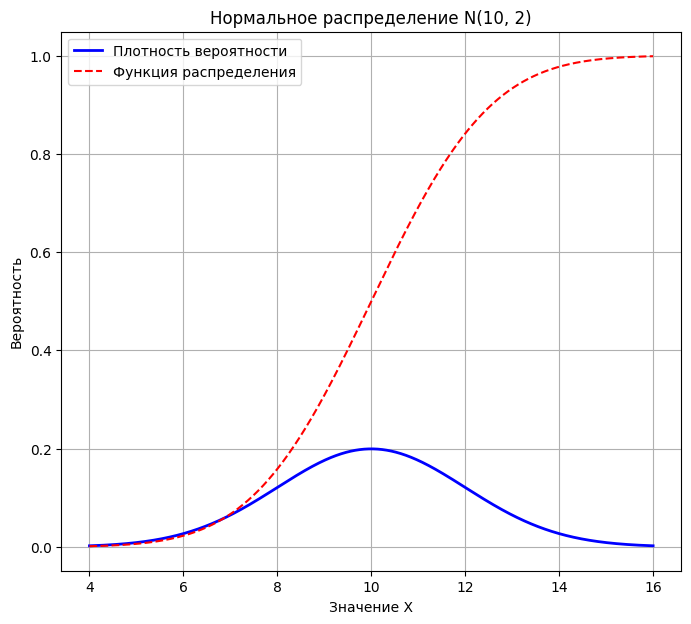

In [2]:
M=10
D=4
sigma=np.sqrt(D)
x = np.linspace(M-3*sigma, M+3*sigma, 1000) #Создает массив из 1000 точек в диапазоне от 10-3б до 10+3б. Это «правило трех сигм» — в этот интервал попадает 99.7% всех значений.
f_x1 = norm.pdf(x, M, sigma) #loc, scale - положение(вершина) и масштаб(ширина и высота) , плотность расп-я
F_x1 = norm.cdf(x, M, sigma) #функция расп-я

plt.figure(figsize=(8, 7))
plt.plot(x, f_x1, label='Плотность вероятности', color='blue', lw=2)
plt.plot(x, F_x1, label='Функция распределения', color='red', linestyle='--')

plt.title('Нормальное распределение N(10, 2)') #Добавляют заголовок и подписи к осям X и Y
plt.xlabel('Значение X')
plt.ylabel('Вероятность')
plt.legend() #Отображает легенду (список линий) в углу.
plt.grid(True) #Включает сетку для удобства чтения значений.
plt.show()

Вероятности:
 P(X<11): 0.6915
 P(X>5): 0.9938
 P(4<x<12): 0.8400


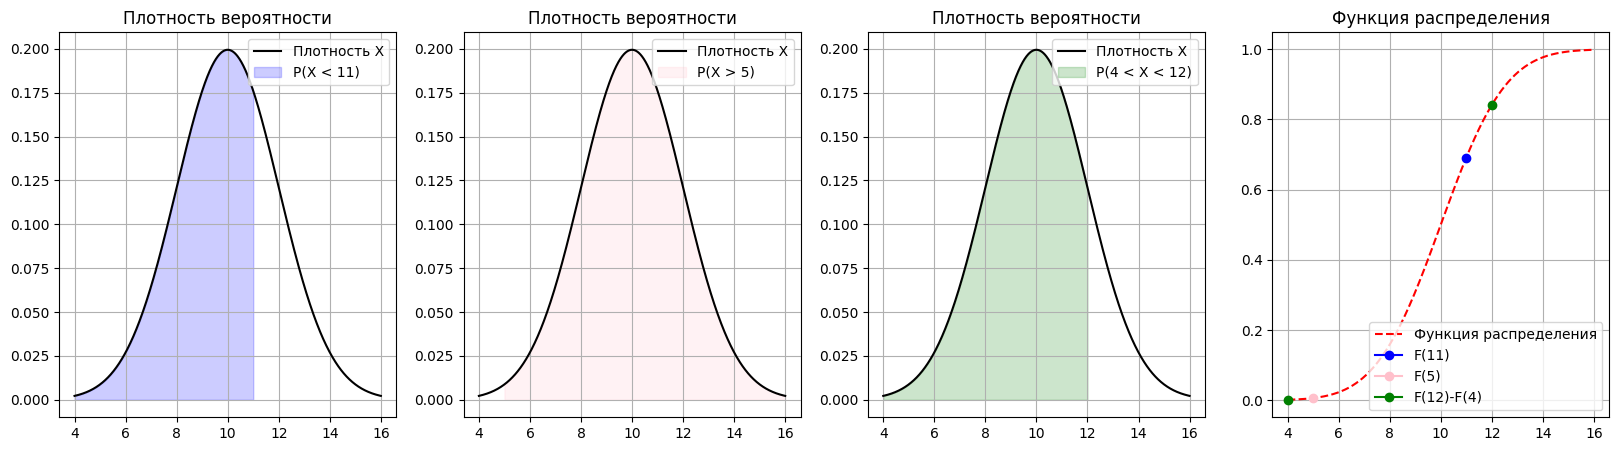

In [9]:
p_11 = norm.cdf(11, loc=M, scale=sigma)
F_5 = norm.cdf(5, loc=M, scale=sigma)
p_5 = 1 - F_5
p_4_12 = norm.cdf(12, loc=M, scale=sigma) - norm.cdf(4, loc=M, scale=sigma)
print(f"Вероятности:\n P(X<11): {p_11:.4f}\n P(X>5): {p_5:.4f}\n P(4<x<12): {p_4_12:.4f}")

plt.figure(figsize=(20, 5))

# Плотность распределения
# P(X < 11)
plt.subplot(1, 4, 1) #рисуем первый график
plt.plot(x, f_x1, color='black', label='Плотность X')
x1 = np.linspace(M-3*sigma, 11, 100)
plt.fill_between(x1, norm.pdf(x1, M, sigma), color='blue', alpha=0.2, label='P(X < 11)')
plt.title('Плотность вероятности')
plt.legend()
plt.grid(True)

# P(X > 5)
plt.subplot(1, 4, 2)
plt.plot(x, f_x1, color='black', label='Плотность X')
x2 = np.linspace(5, M+3*sigma, 100)
plt.fill_between(x2, norm.pdf(x2, M, sigma), color='pink', alpha=0.2, label='P(X > 5)')
plt.title('Плотность вероятности')
plt.legend()
plt.grid(True)

# P(4 < X < 12)
plt.subplot(1, 4, 3)
plt.plot(x, f_x1, color='black', label='Плотность X')
x3 = np.linspace(4, 12, 100)
plt.fill_between(x3, norm.pdf(x3, M, sigma), color='green', alpha=0.2, label='P(4 < X < 12)')
plt.title('Плотность вероятности')
plt.legend()
plt.grid(True)

# Функция распределения
plt.subplot(1, 4, 4)
plt.title('Функция распределения')
plt.plot(x, F_x1, label='Функция распределения', color='red', linestyle='--')

#Точка для P(X < 11)
plt.plot(11, p_11, marker='o', color='blue', label='F(11)')

# Точка для P(X > 5)
plt.plot(5, F_5, marker='o', color='pink', label='F(5)')

# Точки для интервала 4 < X < 12
plt.plot(4, norm.cdf(4, M, sigma), marker='o', color='green')
plt.plot(12, norm.cdf(12, M, sigma), marker='o', color='green', label='F(12)-F(4)')

plt.legend()
plt.grid(True)
plt.show()

1: P(8.0 < X < 12.0) = 0.6827 (теоретически 0.683)
2: P(6.0 < X < 14.0) = 0.9545 (теоретически 0.954)
3: P(4.0 < X < 16.0) = 0.9973 (теоретически 0.997)


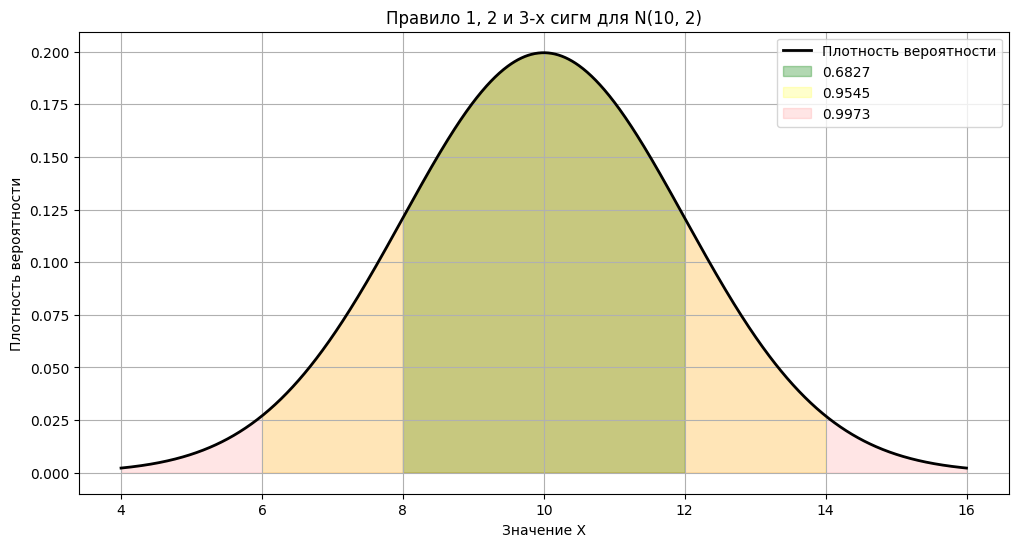

In [10]:
p_1sigma = norm.cdf(M + sigma, M, sigma) - norm.cdf(M - sigma, M, sigma)
p_2sigma = norm.cdf(M + 2*sigma, M, sigma) - norm.cdf(M - 2*sigma, M, sigma)
p_3sigma = norm.cdf(M + 3*sigma, M, sigma) - norm.cdf(M - 3*sigma, M, sigma)

print(f"1: P({M-sigma} < X < {M+sigma}) = {p_1sigma:.4f} (теоретически 0.683)")
print(f"2: P({M-2*sigma} < X < {M+2*sigma}) = {p_2sigma:.4f} (теоретически 0.954)")
print(f"3: P({M-3*sigma} < X < {M+3*sigma}) = {p_3sigma:.4f} (теоретически 0.997)")

# Создаем график
plt.figure(figsize=(12, 6))

# Основная линия плотности
plt.plot(x, f_x1, 'black', lw=2, label='Плотность вероятности')

# Закрашиваем интервалы с разной прозрачностью
# 1 сигма
x1 = np.linspace(M - sigma, M + sigma, 200)
plt.fill_between(x1, norm.pdf(x1, M, sigma), color='green', alpha=0.3, label=f'{p_1sigma:.4f}')

# 2 сигмы
x2 = np.linspace(M - 2*sigma, M + 2*sigma, 200)
plt.fill_between(x2, norm.pdf(x2, M, sigma), color='yellow', alpha=0.2, label=f'{p_2sigma:.4f}')

# 3 сигмы
x3 = np.linspace(M - 3*sigma, M + 3*sigma, 200)
plt.fill_between(x3, norm.pdf(x3, M, sigma), color='red', alpha=0.1, label=f'{p_3sigma:.4f}')

plt.title('Правило 1, 2 и 3-х сигм для N(10, 2)')
plt.xlabel('Значение X')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()

2. Случайная величина Y имеет экспоненциальное распределение, M[Y] = 2.

Построить для нее функцию и плотность распределения вероятностей.

Вычислить вероятности P(Y < 3), P(Y > 2), P(1 < Y < 2.5).

Отобразить, вероятности на графиках функции  и плотности вероятностей.

Проверить выполнение правила «3-сигм» для Y , отобразить это правило на графике плотности вероятностей.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

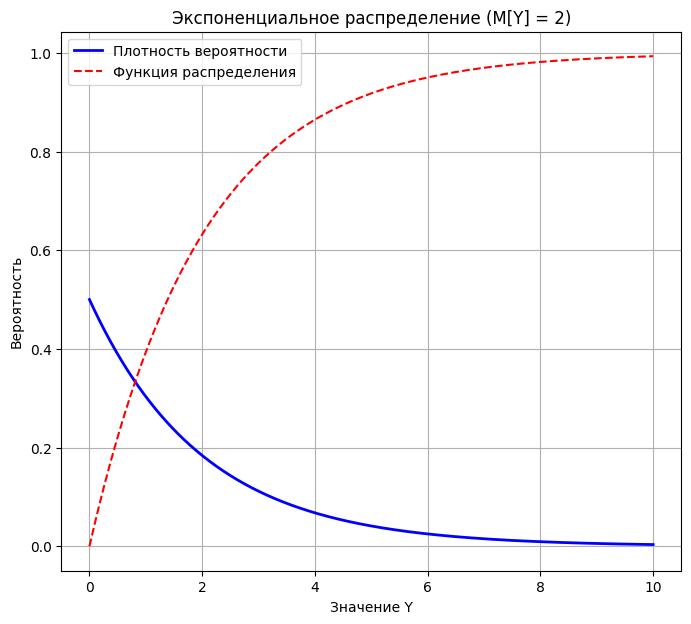

In [26]:
m_y = 2 
sigma = 2
x = np.linspace(0, 10, 1000)

f_y = expon.pdf(x, scale=m_y) # Плотность вероятности
F_y = expon.cdf(x, scale=m_y) # Функция распределения

plt.figure(figsize=(8, 7))
plt.plot(x, f_y, label='Плотность вероятности', color='blue', lw=2)
plt.plot(x, F_y, label='Функция распределения', color='red', linestyle='--')

plt.title('Экспоненциальное распределение (M[Y] = 2)')
plt.xlabel('Значение Y')
plt.ylabel('Вероятность')
plt.legend()
plt.grid(True)
plt.show()

Вероятности:
 P(Y < 3): 0.7769
 P(Y > 2): 0.3679
 P(1 < Y < 2.5): 0.3200


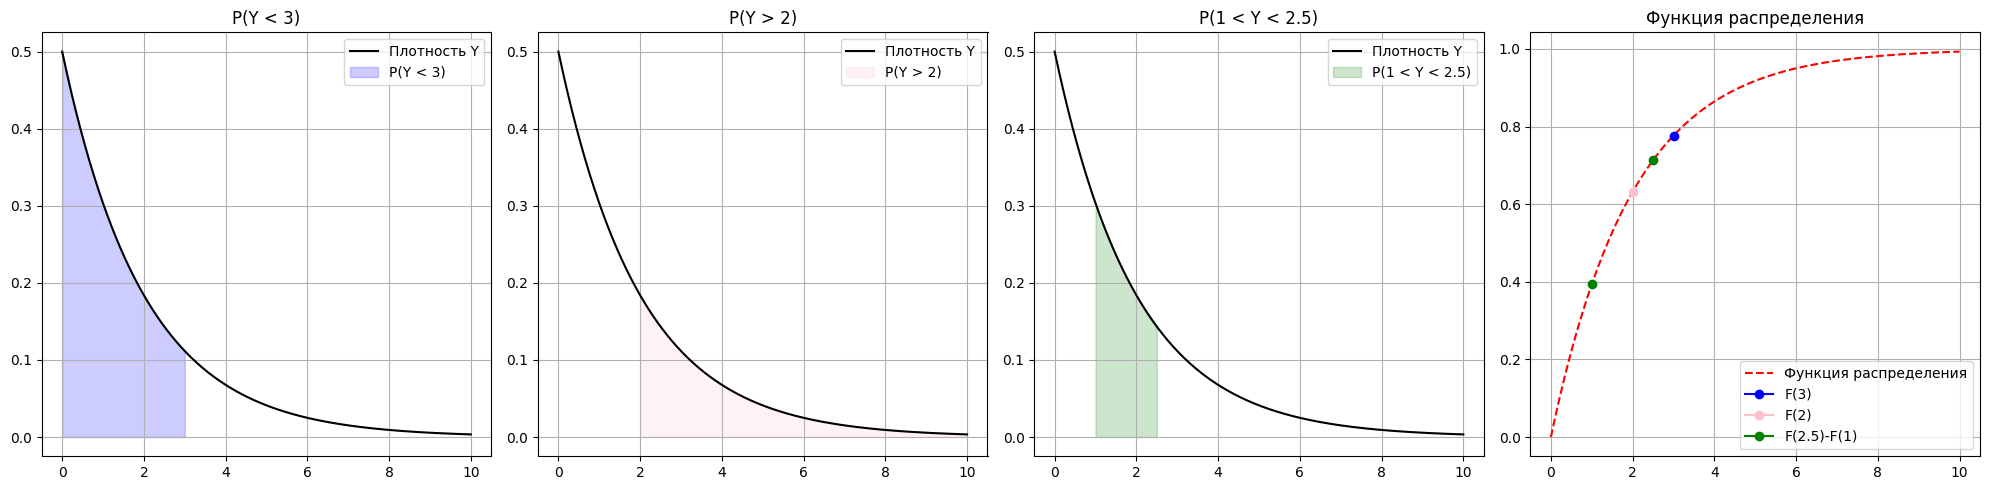

In [27]:
p_y_less_3 = expon.cdf(3, scale=m_y)           # P(Y < 3)
p_y_more_2 = 1 - expon.cdf(2, scale=m_y)       # P(Y > 2)
p_y_range = expon.cdf(2.5, scale=m_y) - expon.cdf(1, scale=m_y) # P(1 < Y < 2.5)

print(f"Вероятности:\n P(Y < 3): {p_y_less_3:.4f}\n P(Y > 2): {p_y_more_2:.4f}\n P(1 < Y < 2.5): {p_y_range:.4f}")

plt.figure(figsize=(20, 5))

# График 1: P(Y < 3)
plt.subplot(1, 4, 1)
plt.plot(x, f_y, color='black', label='Плотность Y')
x1 = np.linspace(0, 3, 100)
plt.fill_between(x1, expon.pdf(x1, scale=m_y), color='blue', alpha=0.2, label='P(Y < 3)')
plt.title('P(Y < 3)')
plt.legend()
plt.grid(True)

# График 2: P(Y > 2)
plt.subplot(1, 4, 2)
plt.plot(x, f_y, color='black', label='Плотность Y')
x2 = np.linspace(2, 10, 100)
plt.fill_between(x2, expon.pdf(x2, scale=m_y), color='pink', alpha=0.2, label='P(Y > 2)')
plt.title('P(Y > 2)')
plt.legend()
plt.grid(True)

# График 3: P(1 < Y < 2.5)
plt.subplot(1, 4, 3)
plt.plot(x, f_y, color='black', label='Плотность Y')
x3 = np.linspace(1, 2.5, 100)
plt.fill_between(x3, expon.pdf(x3, scale=m_y), color='green', alpha=0.2, label='P(1 < Y < 2.5)')
plt.title('P(1 < Y < 2.5)')
plt.legend()
plt.grid(True)

# График 4: Функция распределения и точки
plt.subplot(1, 4, 4)
plt.plot(x, F_y, label='Функция распределения', color='red', linestyle='--')
plt.plot(3, expon.cdf(3, scale=m_y), marker='o', color='blue', label='F(3)')
plt.plot(2, expon.cdf(2, scale=m_y), marker='o', color='pink', label='F(2)')
plt.plot(1, expon.cdf(1, scale=m_y), marker='o', color='green')
plt.plot(2.5, expon.cdf(2.5, scale=m_y), marker='o', color='green', label='F(2.5)-F(1)')
plt.title('Функция распределения')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1: P(0 < Y < 4) = 0.8647 (вместо 0.683)
2: P(0 < Y < 6) = 0.9502 (вместо 0.954)
3: P(0 < Y < 8) = 0.9817 (вместо 0.997)


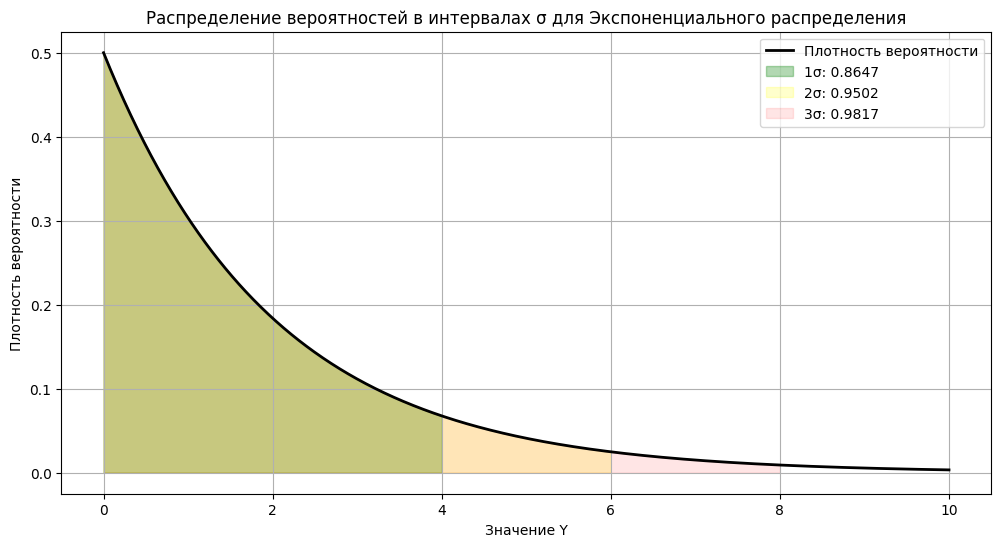

In [29]:
# Вычисляем вероятности для интервалов (с учетом, что Y >= 0)
p_1sigma = expon.cdf(m_y) - expon.cdf(max(0, m_y - sigma), scale=m_y)
p_2sigma = expon.cdf(m_y + 2*sigma, scale=m_y) - expon.cdf(max(0, m_y - 2*sigma), scale=m_y)
p_3sigma = expon.cdf(m_y + 3*sigma, scale=m_y) - expon.cdf(max(0, m_y - 3*sigma), scale=m_y)

print(f"1: P({max(0, m_y-sigma)} < Y < {m_y+sigma}) = {p_1sigma:.4f} (вместо 0.683)")
print(f"2: P({max(0, m_y-2*sigma)} < Y < {m_y+2*sigma}) = {p_2sigma:.4f} (вместо 0.954)")
print(f"3: P({max(0, m_y-3*sigma)} < Y < {m_y+3*sigma}) = {p_3sigma:.4f} (вместо 0.997)")

plt.figure(figsize=(12, 6))
plt.plot(x, f_y, 'black', lw=2, label='Плотность вероятности')

# Закрашиваем интервалы (используем max(0, ...), так как экспоненциальное > 0)
# 1 сигма
x1 = np.linspace(max(0, m_y - sigma), m_y + sigma, 200)
plt.fill_between(x1, expon.pdf(x1, scale=m_y), color='green', alpha=0.3, label=f'1σ: {p_1sigma:.4f}')

# 2 сигмы
x2 = np.linspace(max(0, m_y - 2*sigma), m_y + 2*sigma, 200)
plt.fill_between(x2, expon.pdf(x2, scale=m_y), color='yellow', alpha=0.2, label=f'2σ: {p_2sigma:.4f}')

# 3 сигмы
x3 = np.linspace(max(0, m_y - 3*sigma), m_y + 3*sigma, 200)
plt.fill_between(x3, expon.pdf(x3, scale=m_y), color='red', alpha=0.1, label=f'3σ: {p_3sigma:.4f}')

plt.title('Распределение вероятностей в интервалах σ для Экспоненциального распределения')
plt.xlabel('Значение Y')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()